# Keras tutorial: fully connected MNIST classifier

This tutorial follows the Keras `Sequential` workflow: load data, inspect it,
normalize and flatten images, build a dense network, train it, and evaluate it.

References: [Keras getting started](https://keras.io/getting_started/) and
[Keras MNIST example](https://keras.io/examples/vision/mnist_convnet/).


In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix

keras.utils.set_random_seed(42)
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "keras" and (PROJECT_DIR / "keras").is_dir():
    PROJECT_DIR = PROJECT_DIR / "keras"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"Keras {keras.__version__}; backend: {keras.config.backend()}")


Keras 3.15.1; backend: tensorflow


## 1. Dataset

MNIST contains grayscale images of handwritten digits from 0 through 9. Each
image has shape `28 x 28`, and each label is an integer class.


In [2]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()
assert train_images.shape == (60000, 28, 28)
assert test_images.shape == (10000, 28, 28)
assert train_labels.shape == (60000,)
assert test_labels.shape == (10000,)
assert train_images.dtype == np.uint8
assert set(np.unique(train_labels)) == set(range(10))

print(f"Train images: {train_images.shape}; dtype: {train_images.dtype}")
print(f"Train labels: {train_labels.shape}; dtype: {train_labels.dtype}")
print(f"Test images: {test_images.shape}; dtype: {test_images.dtype}")
print(f"Test labels: {test_labels.shape}; dtype: {test_labels.dtype}")


Train images: (60000, 28, 28); dtype: uint8
Train labels: (60000,); dtype: uint8
Test images: (10000, 28, 28); dtype: uint8
Test labels: (10000,); dtype: uint8


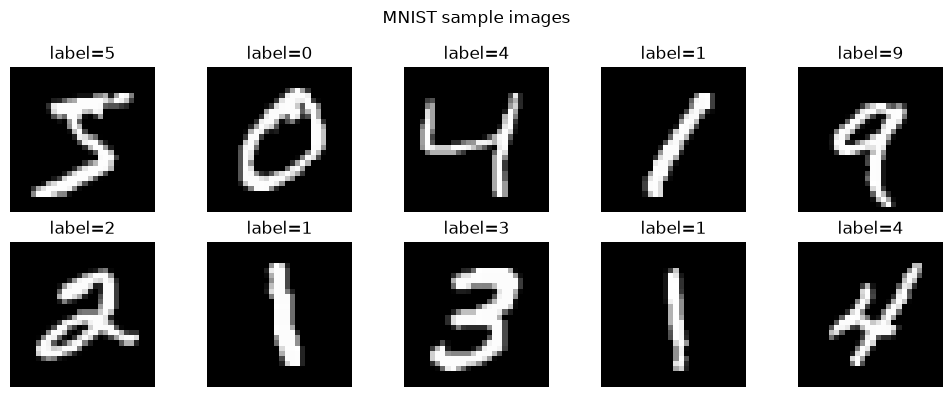

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for axis, image, label in zip(axes.flat, train_images[:10], train_labels[:10]):
    axis.imshow(image, cmap="gray")
    axis.set_title(f"label={label}")
    axis.axis("off")
fig.suptitle("MNIST sample images")
fig.tight_layout()
display(fig)
plt.close(fig)


In [4]:
label_counts = (
    pd.Series(train_labels)
    .value_counts()
    .sort_index()
    .rename_axis("digit")
    .to_frame("count")
)
display(label_counts)


,count
digit,
0,5923
1,6742
2,5958
3,6131
4,5842
5,5421
6,5918
7,6265
8,5851


## 2. Preprocess the images and labels

Dense layers consume a feature vector, so each image is flattened from 784
pixels. Pixel values are normalized from `[0, 255]` to `[0, 1]`. The integer
labels become one-hot vectors for categorical cross-entropy.


In [5]:
train_images = train_images.reshape((len(train_images), 28 * 28)).astype("float32") / 255.0
test_images = test_images.reshape((len(test_images), 28 * 28)).astype("float32") / 255.0
train_targets = keras.utils.to_categorical(train_labels, num_classes=10)
test_targets = keras.utils.to_categorical(test_labels, num_classes=10)

assert train_images.shape == (60000, 784)
assert test_images.shape == (10000, 784)
assert train_targets.shape == (60000, 10)
assert np.isclose(train_images.min(), 0.0)
assert train_images.max() <= 1.0


## 3. Build and compile a fully connected model

The model is `INPUT -> Dense(512, relu) -> Dense(10, softmax)`. The explicit
`Input` layer states the feature shape before the first trainable layer.


In [6]:
network = keras.Sequential(
    [
        keras.Input(shape=(28 * 28,), name="pixels"),
        keras.layers.Dense(512, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ],
    name="mnist_dense_network",
)
network.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
network.summary()


Model: "mnist_dense_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

Total params: 407,050 (1.55 MB)

Trainable params: 407,050 (1.55 MB)

Non-trainable params: 0 (0.00 B)

## 4. Train the model

`fit()` returns a `History` object containing loss and accuracy for each epoch.
A 10% validation split monitors generalization while training.


In [7]:
history = network.fit(
    train_images,
    train_targets,
    epochs=5,
    batch_size=128,
    validation_split=0.10,
    verbose=0,
)
history_frame = pd.DataFrame(history.history)
display(history_frame)


,accuracy,loss,val_accuracy,val_loss
0,0.919259,0.277134,0.967167,0.123226
1,0.966315,0.113577,0.973333,0.091352
2,0.978704,0.073918,0.976833,0.079289
3,0.985056,0.052518,0.979000,0.074567
4,0.989444,0.038063,0.978833,0.074032


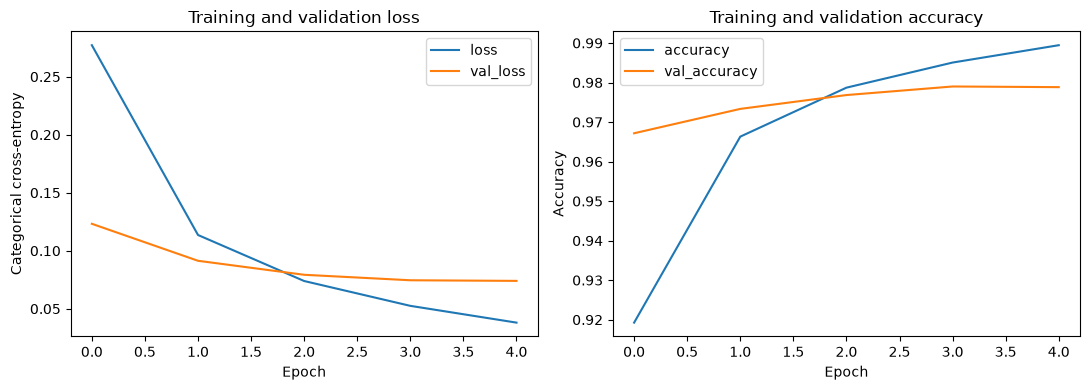

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
history_frame[["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_title("Training and validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Categorical cross-entropy")
history_frame[["accuracy", "val_accuracy"]].plot(ax=axes[1])
axes[1].set_title("Training and validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mnist_tutorial_history.png", dpi=150)
display(fig)
plt.close(fig)


## 5. Evaluate the model

The test set was not used during fitting. We compare its loss and accuracy to
the final training/validation values and inspect the confusion matrix.


In [9]:
test_loss, test_accuracy = network.evaluate(test_images, test_targets, verbose=0)
predicted_labels = np.argmax(network.predict(test_images, verbose=0), axis=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(classification_report(test_labels, predicted_labels, zero_division=0))

cm = confusion_matrix(test_labels, predicted_labels, labels=np.arange(10))
display(pd.DataFrame(cm, index=np.arange(10), columns=np.arange(10)))
pd.DataFrame(
    [{"test_loss": test_loss, "test_accuracy": test_accuracy}]
).to_csv(OUTPUT_DIR / "mnist_tutorial_metrics.csv", index=False)


Test loss: 0.0733
Test accuracy: 0.9777
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.96      0.97      1032
           3       0.96      0.99      0.97      1010
           4       0.97      0.99      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.99      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.95      0.98      0.96       974
           9       0.99      0.95      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



,0,1,2,3,4,5,6,7,8,9
0,970,0,0,1,0,0,5,1,3,0
1,0,1118,2,2,0,2,3,1,7,0
2,4,0,990,8,5,1,2,7,15,0
3,0,0,0,999,0,2,0,5,4,0
4,0,0,2,1,968,0,5,2,0,4
5,1,0,0,10,0,870,6,0,5,0
6,2,2,0,1,2,2,947,0,2,0
7,1,5,6,3,0,0,0,1007,4,2
8,1,0,3,8,4,4,2,2,950,0
9,3,2,0,9,18,4,1,8,6,958
